# Predikcija kategorije proizvoda na osnovu naslova

## Cilj projekta

Cilj projekta je razvoj modela mašinskog učenja koji automatski predviđa kategoriju proizvoda na osnovu njegovog naziva.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Učitavanje podataka

Učitavamo originalni skup podataka `products.csv`. Originalni fajl nećemo menjati, već ćemo nakon analize napraviti novi očišćeni fajl `products_cleaned.csv`.

In [2]:
df = pd.read_csv("../data/products.csv")

df.head()

,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


## 2. Analiza kvaliteta podataka

Pre čišćenja proverićemo strukturu skupa podataka, nazive kolona, nedostajuće vrednosti i duplikate. Na osnovu tih rezultata odredićemo koje korake čišćenja treba primeniti.

In [3]:
print("Dimenzije skupa podataka:", df.shape)

print("\nNazivi kolona:")
print(df.columns.tolist())

print("\nNedostajuće vrednosti:")
print(df.isnull().sum())

print("\nBroj duplikata:", df.duplicated().sum())

Dimenzije skupa podataka: (35311, 8)

Nazivi kolona:
['product ID', 'Product Title', 'Merchant ID', ' Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', ' Listing Date  ']

Nedostajuće vrednosti:
product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64

Broj duplikata: 0


In [4]:
df.columns.tolist()

['product ID',
 'Product Title',
 'Merchant ID',
 ' Category Label',
 '_Product Code',
 'Number_of_Views',
 'Merchant Rating',
 ' Listing Date  ']

In [5]:
df.columns = df.columns.str.strip()

df.columns.tolist()

['product ID',
 'Product Title',
 'Merchant ID',
 'Category Label',
 '_Product Code',
 'Number_of_Views',
 'Merchant Rating',
 'Listing Date']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  str    
 2   Merchant ID      35311 non-null  int64  
 3   Category Label   35267 non-null  str    
 4   _Product Code    35216 non-null  str    
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7   Listing Date     35252 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.2 MB


In [7]:
df.isnull().sum()

product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64

### Zapažanja

Skup podataka sadrži 35.311 proizvoda i 8 kolona. Nema duplikata.

Najviše nedostajućih vrednosti nalazi se u kolonama `Product Title` i `Category Label`, koje su ključne za naš model. Redovi bez naziva proizvoda ili ciljne kategorije neće biti korisni za treniranje i biće uklonjeni.

Nedostajuće vrednosti u ostalim kolonama ćemo obraditi bez uklanjanja celih redova, jer te kolone mogu biti korisne za analizu i dodatne karakteristike.

In [8]:
# Kopija originalnih podataka
df_clean = df.copy()

# Uklanjamo redove bez naziva proizvoda ili ciljne kategorije
df_clean = df_clean.dropna(subset=["Product Title", "Category Label"])

# Uklanjamo višak razmaka iz tekstualnih kolona
text_columns = df_clean.select_dtypes(include="object").columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

# Popunjavamo nedostajuće numeričke vrednosti medianom
numeric_columns = df_clean.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Popunjavamo nedostajuće tekstualne vrednosti
for column in text_columns:
    df_clean[column] = df_clean[column].fillna("Unknown")

print("Broj redova pre čišćenja:", len(df))
print("Broj redova posle čišćenja:", len(df_clean))
print("Broj nedostajućih vrednosti:", df_clean.isnull().sum().sum())

Broj redova pre čišćenja: 35311
Broj redova posle čišćenja: 35096
Broj nedostajućih vrednosti: 0


C:\Users\Ryzen\AppData\Local\Temp\ipykernel_22112\1827191657.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df_clean.select_dtypes(include="object").columns


In [9]:
df_clean.to_csv("../data/products_cleaned.csv", index=False)

print("Fajl products_cleaned.csv je uspešno sačuvan.")

Fajl products_cleaned.csv je uspešno sačuvan.


In [10]:
df_clean.head()

,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


## 4. Analiza kategorija proizvoda

Analiziraćemo broj različitih kategorija i raspodelu proizvoda po kategorijama.

In [11]:
print("Broj različitih kategorija:", df_clean["Category Label"].nunique())

print("\nBroj proizvoda po kategorijama:")
print(df_clean["Category Label"].value_counts())

Broj različitih kategorija: 13

Broj proizvoda po kategorijama:
Category Label
Fridge Freezers     5470
Washing Machines    4015
Mobile Phones       4002
CPUs                3747
TVs                 3541
Fridges             3436
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


In [12]:
category_mapping = {
    "fridge": "Fridges",
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones"
}

df_clean["Category Label"] = df_clean["Category Label"].replace(category_mapping)

print("Broj različitih kategorija nakon sređivanja:",
      df_clean["Category Label"].nunique())

print("\nBroj proizvoda po kategorijama:")
print(df_clean["Category Label"].value_counts())

Broj različitih kategorija nakon sređivanja: 10

Broj proizvoda po kategorijama:
Category Label
Fridge Freezers     5470
Mobile Phones       4057
Washing Machines    4015
CPUs                3831
Fridges             3559
TVs                 3541
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
Name: count, dtype: int64


In [13]:
df_clean.to_csv("../data/products_cleaned.csv", index=False)

print("products_cleaned.csv je ažuriran.")

products_cleaned.csv je ažuriran.


## 5. Rad sa očišćenim podacima

Nakon čišćenja podataka, učitavamo `products_cleaned.csv` i koristimo ga za dalju analizu i izgradnju modela.

In [14]:
df_cleaned = pd.read_csv("../data/products_cleaned.csv")

print("Dimenzije očišćenog skupa:", df_cleaned.shape)
print("Broj kategorija:", df_cleaned["Category Label"].nunique())

Dimenzije očišćenog skupa: (35096, 8)
Broj kategorija: 10


## 6. Raspodela proizvoda po kategorijama

Prikazaćemo koliko proizvoda pripada svakoj kategoriji. Ova analiza nam pomaže da vidimo da li su kategorije približno ravnomerno zastupljene.

In [15]:
category_counts = df_cleaned["Category Label"].value_counts()

print(category_counts)

Category Label
Fridge Freezers     5470
Mobile Phones       4057
Washing Machines    4015
CPUs                3831
Fridges             3559
TVs                 3541
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
Name: count, dtype: int64


### Vizuelizacija raspodele kategorija

Grafički ćemo prikazati broj proizvoda u svakoj kategoriji kako bismo lakše uočili razlike u zastupljenosti kategorija.

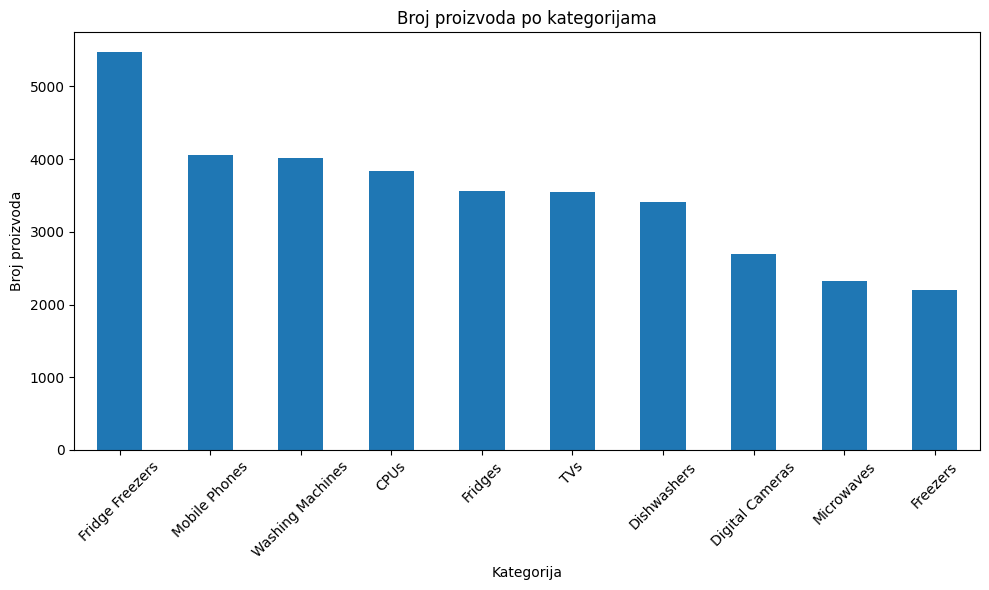

In [16]:
plt.figure(figsize=(10, 6))

category_counts.plot(kind="bar")

plt.title("Broj proizvoda po kategorijama")
plt.xlabel("Kategorija")
plt.ylabel("Broj proizvoda")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Priprema podataka za mašinsko učenje

U ovom koraku pripremićemo podatke za treniranje modela.  
Kao ulaz koristićemo naziv proizvoda (`Product Title`), a cilj će biti kategorija proizvoda (`Category Label`).

In [17]:
X = df_cleaned["Product Title"]
y = df_cleaned["Category Label"]

print("Broj uzoraka:", len(X))
print("Broj kategorija:", y.nunique())

Broj uzoraka: 35096
Broj kategorija: 10


## 8. Pretvaranje teksta u numeričke karakteristike

Nazive proizvoda pretvorićemo u numeričke karakteristike pomoću TF-IDF metode. Na taj način tekstualni podaci mogu da se koriste kao ulaz za model mašinskog učenja.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_tfidf = vectorizer.fit_transform(X)

print("Dimenzije TF-IDF matrice:", X_tfidf.shape)

Dimenzije TF-IDF matrice: (35096, 5000)


## 9. Podela podataka na trening i test skup

Podatke delimo na trening i test skup. Trening skup koristićemo za učenje modela, dok ćemo test skup koristiti za proveru koliko model dobro predviđa kategorije proizvoda na novim podacima.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Broj trening uzoraka:", X_train.shape[0])
print("Broj test uzoraka:", X_test.shape[0])

Broj trening uzoraka: 28076
Broj test uzoraka: 7020


## 10. Treniranje modela

Za klasifikaciju proizvoda koristićemo logističku regresiju. Model će učiti vezu između naziva proizvoda i njegove kategorije na osnovu trening skupa.

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model je uspešno istreniran.")

Model je uspešno istreniran.


## 11. Provera tačnosti modela

Model ćemo testirati na test skupu i izračunati tačnost predviđanja.

In [21]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Tačnost modela:", accuracy)

Tačnost modela: 0.9605413105413105


## 12. Detaljna evaluacija modela

Pored ukupne tačnosti, koristićemo precision, recall i F1-score za svaku kategoriju. Na ovaj način možemo detaljnije da procenimo performanse modela.

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

            CPUs       1.00      0.99      1.00       766
 Digital Cameras       1.00      1.00      1.00       538
     Dishwashers       0.94      0.96      0.95       681
        Freezers       0.98      0.94      0.96       440
 Fridge Freezers       0.95      0.94      0.94      1094
         Fridges       0.90      0.91      0.91       712
      Microwaves       0.99      0.96      0.97       466
   Mobile Phones       0.95      0.99      0.97       812
             TVs       0.98      0.98      0.98       708
Washing Machines       0.95      0.94      0.95       803

        accuracy                           0.96      7020
       macro avg       0.96      0.96      0.96      7020
    weighted avg       0.96      0.96      0.96      7020



## 13. Matrica konfuzije

Matrica konfuzije prikazuje koliko je primeraka iz svake kategorije model pravilno klasifikovao i sa kojim kategorijama ih je najčešće pomešao.

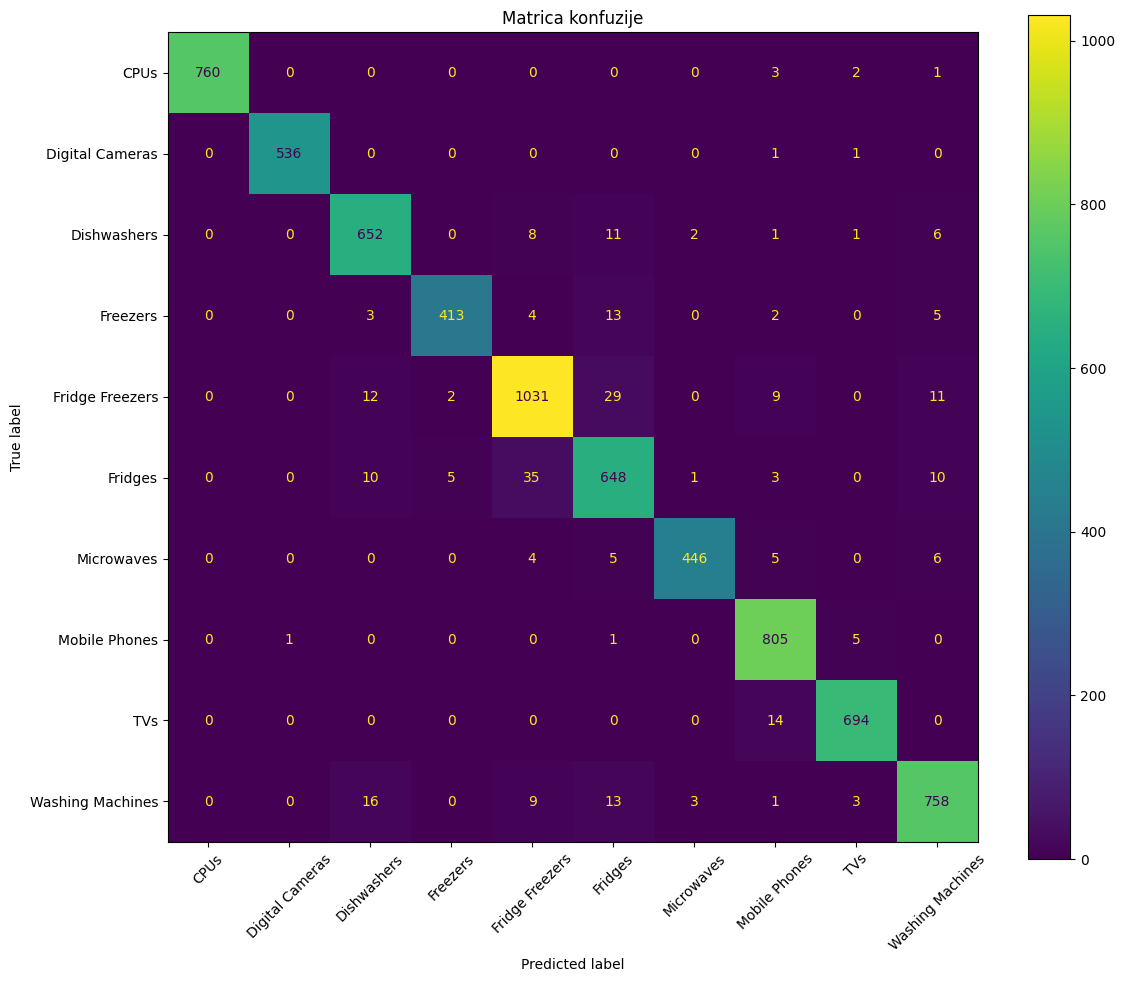

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    ax=ax
)

plt.title("Matrica konfuzije")
plt.tight_layout()
plt.show()

## 14. Treniranje drugog modela

Kako bismo uporedili performanse modela, koristićemo LinearSVC klasifikator. Model ćemo trenirati na istim TF-IDF podacima.

In [24]:
from sklearn.svm import LinearSVC

model_svc = LinearSVC()

model_svc.fit(X_train, y_train)

y_pred_svc = model_svc.predict(X_test)

accuracy_svc = accuracy_score(y_test, y_pred_svc)

print("Tačnost LinearSVC modela:", accuracy_svc)

Tačnost LinearSVC modela: 0.9666666666666667


## 15. Poređenje modela

Uporedićemo rezultate dva trenirana modela na test skupu i odrediti koji model postiže bolje performanse.

In [25]:
print("Poređenje tačnosti modela:")
print("Prvi model:", accuracy_score(y_test, y_pred))
print("Drugi model:", accuracy_score(y_test, y_pred_svc))

Poređenje tačnosti modela:
Prvi model: 0.9605413105413105
Drugi model: 0.9666666666666667


## 16. Čuvanje finalnog modela

Kao finalni model biramo LinearSVC jer je ostvario veću tačnost od prvog modela. Model ćemo sačuvati kako bi kasnije mogao da se koristi za predviđanje kategorije novih proizvoda.

In [26]:
import joblib

joblib.dump(model_svc, "../data/product_category_model.pkl")
joblib.dump(vectorizer, "../data/tfidf_vectorizer.pkl")

print("Finalni model i vektorizator su uspešno sačuvani.")

Finalni model i vektorizator su uspešno sačuvani.


## 17. Interaktivno testiranje modela

U ovom koraku proverićemo kako model predviđa kategoriju za novi proizvod.
Korisnik unosi naziv proizvoda, a model na osnovu TF-IDF vektorizacije predviđa odgovarajuću kategoriju.

In [27]:
import joblib

model = joblib.load("../data/product_category_model.pkl")
vectorizer = joblib.load("../data/tfidf_vectorizer.pkl")

product_name = input("Unesi naziv proizvoda: ")

product_vector = vectorizer.transform([product_name])
prediction = model.predict(product_vector)

print("Predviđena kategorija:", prediction[0])

Predviđena kategorija: Mobile Phones


## 18. Testiranje modela na novim proizvodima

U ovom koraku proverićemo kako finalni model predviđa kategoriju za nove proizvode na osnovu njihovog naziva.

In [28]:
novi_proizvodi = [
    "Apple iPhone 15 Pro 256GB",
    "Samsung 55 inch Smart TV",
    "LG washing machine 8kg",
    "Canon digital camera",
    "Bosch fridge freezer"
]

novi_proizvodi_tfidf = vectorizer.transform(novi_proizvodi)

predikcije = model_svc.predict(novi_proizvodi_tfidf)

for proizvod, kategorija in zip(novi_proizvodi, predikcije):
    print("Proizvod:", proizvod)
    print("Predviđena kategorija:", kategorija)
    print()

Proizvod: Apple iPhone 15 Pro 256GB
Predviđena kategorija: Mobile Phones

Proizvod: Samsung 55 inch Smart TV
Predviđena kategorija: TVs

Proizvod: LG washing machine 8kg
Predviđena kategorija: Washing Machines

Proizvod: Canon digital camera
Predviđena kategorija: Digital Cameras

Proizvod: Bosch fridge freezer
Predviđena kategorija: Fridge Freezers



## 19. Zaključak projekta

U projektu smo napravili model za predikciju kategorije proizvoda na osnovu njegovog naziva.

Podaci su očišćeni i pripremljeni za mašinsko učenje, a tekstualni podaci su pretvoreni u numeričke karakteristike pomoću TF-IDF metode.

Testirana su dva klasifikaciona modela. Prvi model je ostvario tačnost od približno 96.05%, dok je LinearSVC model ostvario tačnost od približno 96.67%.

Na osnovu rezultata izabrali smo LinearSVC kao finalni model. Model i TF-IDF vektorizator su sačuvani kako bi mogli da se koriste za predviđanje kategorija novih proizvoda.

Dodatnim testiranjem na novim nazivima proizvoda pokazano je da model uspešno prepoznaje odgovarajuće kategorije.